# 02 – EDA en cleaning: wanneer en waar fietst New York?

| | |
|---|---|
| **Auteur(s)** | Kobe Vandenberk |
| **Wat** | De data onderzoeken en opschonen, en zo bepalen hoe we het voorspelprobleem opzetten: wat telt als vertrek, welke stations tellen mee, hoe groeperen we stations tot zones (unsupervised), en hoe ziet de target eruit. |
| **Input** | `data/trips_sample.parquet`, `data/station_hour.parquet`, `data/stations.parquet`, `data/audit.json`, `data/weather_2024.parquet` (uit `01_download`) |
| **Output** | Keuzes die in `04_prepare_data` worden toegepast (geen bestanden) |
| **GenAI** | Code en tekst opgesteld met hulp van Claude; keuzes en resultaten nagekeken door Kobe. |

Elke stap volgt hetzelfde patroon: **Vaststelling** (wat zien we, met code als bewijs) → **Keuze** (wat doen we ermee) → **Waarom**.

Het verhaal dat we willen vertellen: *wanneer* en *waar* vertrekken er fietsen, en wat bepaalt dat? Dat bepaalt welke kenmerken het model nodig heeft.

## 0. Imports en data

In [1]:
import json

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import citibike as cb

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3})
GREEN, ORANGE, INK = "#2f6f4f", "#c47f00", "#17201b"

sample = pd.read_parquet(cb.DATA_DIR / "trips_sample.parquet")
station_hour = pd.read_parquet(cb.DATA_DIR / "station_hour.parquet")
stations = pd.read_parquet(cb.DATA_DIR / "stations.parquet")
audit = pd.json_normalize(json.loads((cb.DATA_DIR / "audit.json").read_text())).set_index("month")
weather = pd.read_parquet(cb.DATA_DIR / f"weather_{cb.YEAR}.parquet")
print(f"steekproef: {len(sample):,} ritten | station-uren: {len(station_hour):,} | stations: {len(stations):,}")

steekproef: 442,442 ritten | station-uren: 9,535,664 | stations: 2,280


## 1. Kolomnamen en types
**Vaststelling:** sinds 2021 gebruikt Citi Bike overal dezelfde kolomnamen in `snake_case` (vroeger o.a. `starttime`, `usertype`). Alle 12 maanden van 2024 hebben exact dezelfde 13 kolommen, dus hernoemen is niet nodig. Wel staat alles als tekst in de CSV: de types zetten we zelf (datums, coördinaten).

In [2]:
sample.dtypes.to_frame("type in de ruwe steekproef").T

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,source_month
type in de ruwe steekproef,object,object,object,object,object,object,object,object,object,object,object,object,object,object


In [3]:
trips = cb.parse_chunk(sample)          # zelfde omzetting als in 01
trips[["started_at", "ended_at", "start_lat", "duration_min"]].dtypes.to_frame("na omzetting").T

,started_at,ended_at,start_lat,duration_min
na omzetting,datetime64[ns],datetime64[ns],float64,float64


## 2. Ontbrekende waarden en wat telt als "vertrek"
**Vaststelling (op alle 44 miljoen rijen, uit de audit van 01):**

In [4]:
missing = pd.DataFrame(audit.filter(like="missing.").sum().rename(lambda c: c.replace("missing.", "")), columns=["ontbrekend"])
missing["%"] = (missing["ontbrekend"] / audit["rows"].sum() * 100).round(3)
missing.T

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
ontbrekend,0.0,0.0,0.0,0.0,29835.000,29835.000,114545.000,122573.000,29835.000,29835.000,122304.000,122304.000,0.0
%,0.0,0.0,0.0,0.0,0.067,0.067,0.259,0.277,0.067,0.067,0.276,0.276,0.0


- `start_station_*` en `start_lat/lng` ontbreken **samen** (zelfde aantal): een rit zonder startstation heeft ook geen locatie.
- `end_*` ontbreekt vaker: ritten die niet aan een station eindigden (fiets verloren, gestolen, of een e-bike die buiten een station werd achtergelaten).

**Keuze:**
- Ontbreekt de **start** → rit weglaten: we kunnen hem aan geen station of zone toekennen. Dat is ± 0,05% van de ritten.
- Ontbreekt het **einde** → rit behouden: de fiets is wél vertrokken, en voor de vraag tellen we vertrekken.

**Waarom niet invullen?** Een startstation raden (bv. het dichtstbijzijnde bij... niets) kan niet: er is geen enkele locatie-informatie. Met 0,05% is weglaten verwaarloosbaar.

In [5]:
check = trips.assign(missing_end=trips["end_station_id"].isna())
print("Aandeel e-bikes bij ritten zonder eindstation:", f"{(check.loc[check.missing_end, 'rideable_type'] == 'electric_bike').mean():.0%}",
      "| bij alle ritten:", f"{(check['rideable_type'] == 'electric_bike').mean():.0%}")
print("Mediane duur (min) zonder eindstation:", round(check.loc[check.missing_end, "duration_min"].median(), 1),
      "| alle ritten:", round(check["duration_min"].median(), 1))

Aandeel e-bikes bij ritten zonder eindstation: 91% | bij alle ritten: 66%
Mediane duur (min) zonder eindstation: 69.2 | alle ritten: 9.1


**Interpretatie:** ritten zonder eindstation zijn voor 91% e-bikes (tegenover 66% van alle ritten) en duren mediaan 69 minuten in plaats van 9. Dat past bij e-bikes die niet correct in een station werden teruggezet, of fietsen die verloren of gestolen werden. Het zijn echte vertrekken: behouden.

**Duplicaten:** de audit telde per maand dubbele `ride_id`'s:

In [6]:
print("Dubbele ride_id's in 2024:", int(audit["duplicate_ride_ids"].sum()))

Dubbele ride_id's in 2024: 0


## 3. Station-id's: hetzelfde station, twee namen
**Vaststelling:** bij het testen van `01` zagen we hetzelfde station als `3423.10` én `3423.1`. Officiële id's hebben de vorm `1234.56`. In sommige CSV-delen is de kolom blijkbaar als **getal** opgeslagen, waardoor een eindnul wegvalt.

In [7]:
raw_ids = sample["start_station_id"].dropna()
one_decimal = raw_ids[raw_ids.str.fullmatch(r"\d+\.\d")]
print(f"Id's met één decimaal in de steekproef: {len(one_decimal):,} ({len(one_decimal) / len(raw_ids):.1%})")
example = one_decimal.iloc[0]
print(f"Voorbeeld '{example}' -> zelfde naam als '{example}0'?",
      sample.loc[sample.start_station_id == example, "start_station_name"].iloc[0], "|",
      sample.loc[sample.start_station_id == example + "0", "start_station_name"].head(1).tolist())
print("Hersteld over heel 2024 (audit):", f"{int(audit['station_id_fixed'].sum()):,}")

Id's met één decimaal in de steekproef: 3,503 (0.8%)
Voorbeeld '5997.1' -> zelfde naam als '5997.10'? W 12 St & Hudson St | ['W 12 St & Hudson St']
Hersteld over heel 2024 (audit): 350,934


**Keuze:** `normalize_station_id` zet een id met één decimaal om naar twee decimalen (`3423.1` → `3423.10`). Tekst-id's zoals `HB101` blijven ongemoeid.

**Waarom het ertoe doet:** anders splitst één station in twee "stations" met elk de helft van de ritten. Voor zones maakt dat weinig uit (zelfde coördinaten), maar de stationslijst zou te lang zijn en per-station-analyses zouden fout zijn.

## 4. Ritduur: uitschieters
**Vaststelling:**

count    442442.0
mean         13.5
std          33.0
min           1.0
1%            1.4
50%           9.1
99%          63.7
99.9%       327.1
max        1559.9
Korter dan 1 minuut: 0 | langer dan 24 uur (alle data, audit): 10936 | negatief (audit): 319


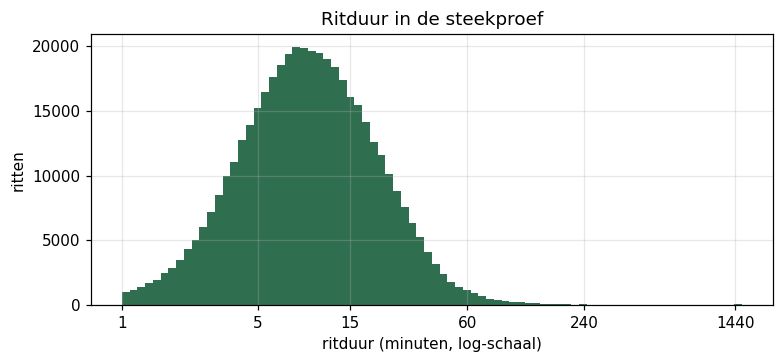

In [8]:
d = trips["duration_min"]
print(d.describe(percentiles=[.01, .5, .99, .999]).round(1).to_string())
print("Korter dan 1 minuut:", int((d < 1).sum()), "| langer dan 24 uur (alle data, audit):", int(audit["duration_over_24h"].sum()),
      "| negatief (audit):", int(audit["duration_negative"].sum()))

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(np.log10(d.clip(lower=1).to_numpy()), bins=80, color=GREEN)
ax.set(xlabel="ritduur (minuten, log-schaal)", ylabel="ritten", title="Ritduur in de steekproef")
ax.set_xticks(np.log10([1, 5, 15, 60, 240, 1440]), ["1", "5", "15", "60", "240", "1440"])
plt.show()

**Interpretatie:**
- De ritduur is sterk **rechtsscheef**: mediaan 9 minuten, 99% duurt korter dan ruim een uur, maar er zijn ritten tot 26 uur (10.936 ritten langer dan 24 uur in heel 2024, 0,025%). Op een log-schaal ziet de verdeling er bijna normaal uit.
- Er zijn **geen ritten korter dan 1 minuut**: die heeft Citi Bike er zelf al uitgehaald.
- **319 ritten hebben een negatieve duur**, allemaal in november. Hieronder het bewijs dat ze allemaal tijdens het **terugzetten van de klok** starten (3 november, 2u wordt weer 1u): een rit die om 1:50 (zomertijd) vertrekt en om 1:10 (wintertijd) aankomt, lijkt 40 minuten "terug in de tijd" te gaan. Het zijn dus geen fouten in het vertrek, alleen in de duur.


In [9]:
# Alle ritten met negatieve duur zitten in november: wanneer starten ze?
negative = pd.concat(t.loc[t["duration_min"] < 0, ["started_at", "ended_at", "duration_min"]]
                     for t in map(cb.parse_chunk, cb.iter_chunks(cb.RAW_DIR / "202411-citibike-tripdata.zip")))
print(f"{len(negative)} ritten, start tussen {negative['started_at'].min()} en {negative['started_at'].max()}")
negative.describe().loc[["min", "max"]]

319 ritten, start tussen 2024-11-03 01:18:30.702000 en 2024-11-03 01:59:59.286000


,started_at,ended_at,duration_min
min,2024-11-03 01:18:30.702000,2024-11-03 01:00:00.449000,-57.980767
max,2024-11-03 01:59:59.286000,2024-11-03 01:57:03.555000,-1.118767


**Keuze:** we filteren **niet** op ritduur.

**Waarom:** onze target is het **aantal vertrekken**, niet de duur. Een rit van 6 uur is een fiets die vertrok: die vraag was er echt. (Voor Brents ritduurmodel is filteren wél nodig; daar zou zo'n rit het gemiddelde vertekenen.) Ritten korter dan een minuut (valse starts, meteen terugzetten) heeft Citi Bike zelf al uit de publieke data gehaald, zoals ze op hun site vermelden.

## 5. Stations: welke tellen mee?
**Vaststelling:** naast gewone stations (`1234.56`) bestaan er id's met een andere vorm.

In [10]:
st = cb.clean_stations(stations)
odd = st[~st["start_station_id"].str.fullmatch(r"\d+\.\d\d")]
odd.sort_values("trips", ascending=False)[["start_station_id", "name", "trips", "reason"]].head(15)

,start_station_id,name,trips,reason
2275,SYS016,Morgan Bike Mechanics,1601,geen publiek station
2279,Shop Morgan,Shop Morgan,672,geen publiek station
1338,6569.09_,W 35 St & 9 Ave,556,
2278,SYS038,Morgan Loading Docks,540,geen publiek station
2277,SYS033,Pier 40 X2,76,geen publiek station
1159,6247.06_Pillar,Pillar W 27 St & 7 Ave,70,
2273,Lab - NYC,Lab - NYC,8,geen publiek station
2270,JC109,Bergen Ave & Sip Ave,8,Jersey City / Hoboken (apart systeem)
2274,Lab - NYC - Monolith,Lab - NYC - M,8,geen publiek station
2267,JC103,Journal Square,7,Jersey City / Hoboken (apart systeem)


In [11]:
print(st.groupby(st["reason"].replace("", "behouden"))["trips"].agg(stations="size", vertrekken="sum"))

                                       stations  vertrekken
reason                                                     
Jersey City / Hoboken (apart systeem)        63         168
behouden                                   2210    44270300
geen publiek station                          7        2906


- `SYS…` en `Lab - NYC` zijn **interne locaties** (werkplaats, laadkades): fietsen die daar "vertrekken" zijn onderhoud of herverdeling door Citi Bike zelf, geen klantenvraag.
- `JC…`/`HB…` zijn stations in **Jersey City en Hoboken**. Die hebben een eigen dataset (`JC-…`-bestanden); in de NYC-bestanden staan er maar enkele ritten van.

**Keuze:** deze stations weglaten (`clean_stations`). Het gaat om een verwaarloosbaar aantal vertrekken, maar het zijn geen ritten van het systeem dat we willen voorspellen.

**Coördinaten:** alle behouden stations liggen in de NYC-afbakening. Kaart van de stations, grootte = aantal vertrekken:

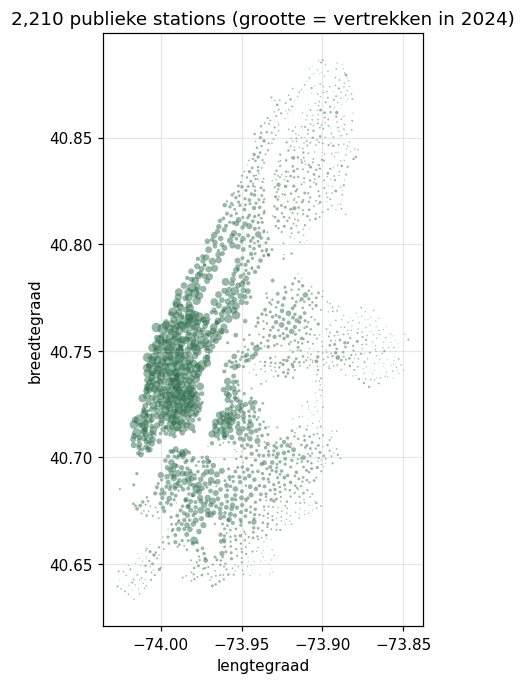

In [12]:
public = st[st["keep"]]
fig, ax = plt.subplots(figsize=(6, 7))
ax.scatter(public["lng"], public["lat"], s=public["trips"] / public["trips"].max() * 60, c=GREEN, alpha=.5, lw=0)
ax.set(title=f"{len(public):,} publieke stations (grootte = vertrekken in 2024)", xlabel="lengtegraad", ylabel="breedtegraad")
ax.set_aspect(1 / np.cos(np.radians(40.73)))
plt.show()

**Interpretatie:** de kaart toont de vorm van het netwerk: Manhattan (de lange strook), Brooklyn (zuiden), Queens (oosten) en de Bronx (noorden). De grootste bollen zitten in Midtown en Lower Manhattan, en in Williamsburg (Brooklyn). Alle 2.211 behouden stations liggen in NYC; geen enkele coördinaat valt erbuiten (`outside_nyc` = 0 in de audit).

## 6. Categorische kolommen
`rideable_type` en `member_casual` zijn categorieën met weinig waarden. We zetten ze om naar het type `category` (minder geheugen, en duidelijk dat het geen vrije tekst is). Weekdagen en maanden zijn **geordende** categorieën: maandag < dinsdag < ..., wat grafieken in de juiste volgorde zet.

In [13]:
trips["rideable_type"] = trips["rideable_type"].astype("category")
trips["member_casual"] = trips["member_casual"].astype("category")
days = ["ma", "di", "wo", "do", "vr", "za", "zo"]
trips["weekday"] = pd.Categorical.from_codes(trips["started_at"].dt.dayofweek, categories=days, ordered=True)
print(trips["rideable_type"].value_counts(normalize=True).round(3).to_string())
print(trips["member_casual"].value_counts(normalize=True).round(3).to_string())
pd.crosstab(trips["started_at"].dt.month.rename("maand"), trips["rideable_type"], normalize="index").round(2).T

rideable_type
electric_bike    0.661
classic_bike     0.339


member_casual
member    0.806
casual    0.194


maand,1,2,3,4,5,6,7,8,9,10,11,12
rideable_type,,,,,,,,,,,,
classic_bike,0.36,0.36,0.35,0.35,0.35,0.35,0.34,0.33,0.33,0.33,0.32,0.3
electric_bike,0.64,0.64,0.65,0.65,0.65,0.65,0.66,0.67,0.67,0.67,0.68,0.7


**Interpretatie:** twee derde van de ritten gebeurt met een **e-bike**, en dat aandeel stijgt gestaag over het jaar (64% naar 70%). 81% van de ritten is van een **member** (abonnee). Deze kolommen gebruiken we niet als *kenmerk* voor het model (bij een voorspelling van de vraag weet je niet wie er zal fietsen), maar wel om het gedrag te begrijpen (zie hieronder).

## 7. Wanneer wordt er gefietst?
Vanaf hier gebruiken we de volledige telling (alle vertrekken van publieke stations), niet meer de steekproef.

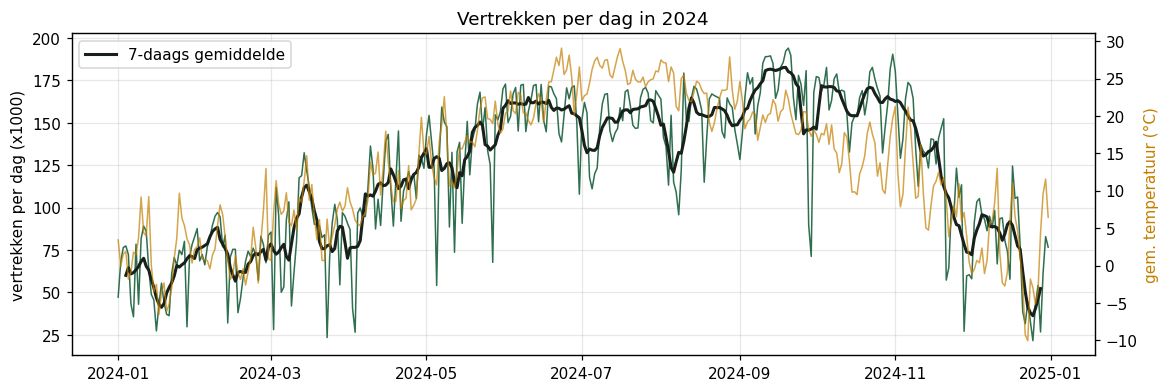

Correlatie (Spearman) dagtotaal ~ temperatuur: 0.77


,trips,temperature_c,precipitation_mm
time,,,
2024-12-25,21562,-3.0,0.0
2024-03-23,23396,6.2,63.2
2024-04-03,26526,6.1,25.0
2024-12-28,26708,4.4,5.5
2024-11-28,27089,7.1,17.9


In [14]:
kept = set(public["start_station_id"])
city = (station_hour[station_hour["start_station_id"].isin(kept) & (station_hour["time"].dt.year == cb.YEAR)]
        .groupby("time")[["trips", "members", "electric"]].sum()
        .reindex(pd.date_range(f"{cb.YEAR}-01-01", f"{cb.YEAR}-12-31 23:00", freq="h"), fill_value=0)
        .rename_axis("time").reset_index().merge(weather, on="time"))
daily = city.set_index("time").resample("D").agg({"trips": "sum", "temperature_c": "mean", "precipitation_mm": "sum"})

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(daily.index, daily["trips"] / 1000, color=GREEN, lw=1)
ax.plot(daily["trips"].rolling(7, center=True).mean() / 1000, color=INK, lw=2, label="7-daags gemiddelde")
ax.set(ylabel="vertrekken per dag (x1000)", title="Vertrekken per dag in 2024")
ax2 = ax.twinx()
ax2.plot(daily.index, daily["temperature_c"], color=ORANGE, lw=1, alpha=.7)
ax2.set_ylabel("gem. temperatuur (°C)", color=ORANGE); ax2.grid(False)
ax.legend(loc="upper left")
plt.show()
print("Correlatie (Spearman) dagtotaal ~ temperatuur:", round(daily["trips"].corr(daily["temperature_c"], method="spearman"), 2))
daily.nsmallest(5, "trips").round(1)

**Interpretatie:**
- Een duidelijk **seizoenspatroon**: rond 50.000 vertrekken per dag in januari, 150.000 tot 190.000 van juni tot oktober. Het dagtotaal volgt de temperatuur (Spearman ρ = 0,77).
- Binnen elke week zie je **diepe dalen**. Dat zijn bijna altijd regendagen: de rustigste dagen buiten de kerstperiode zijn 23 maart (63 mm regen) en 3 april (25 mm). Kerstmis is de rustigste dag van het jaar (koud, feestdag).
- De piek ligt in **september/oktober**, niet in juli: na de zomervakantie fietsen forenzen en studenten weer, terwijl het nog warm is.

**Gevolg voor het model:** temperatuur, neerslag, maand en feestdagen moeten erin.

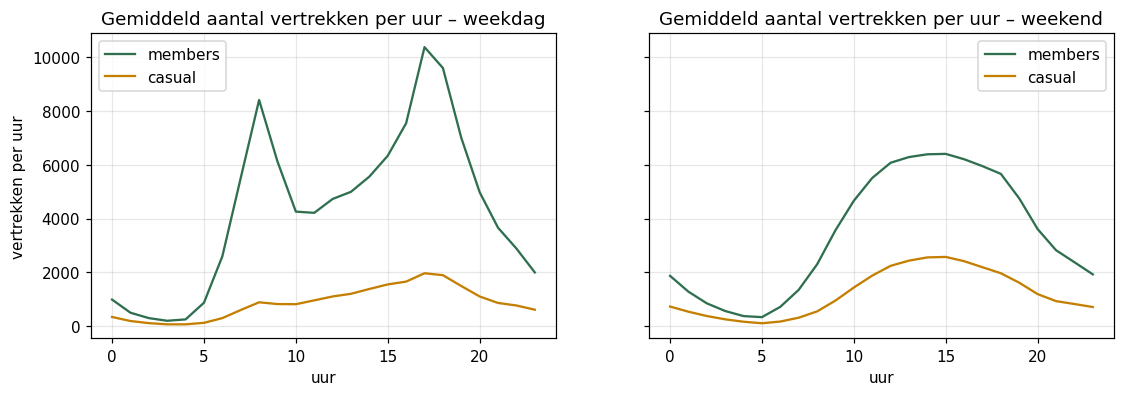

In [15]:
city["hour"] = city["time"].dt.hour
city["daytype"] = np.where(city["time"].dt.dayofweek >= 5, "weekend", "weekdag")
city["casual"] = city["trips"] - city["members"]
profile = city.groupby(["daytype", "hour"])[["members", "casual"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, daytype in zip(axes, ["weekdag", "weekend"]):
    profile.loc[daytype].plot(ax=ax, color=[GREEN, ORANGE])
    ax.set(title=f"Gemiddeld aantal vertrekken per uur – {daytype}", xlabel="uur", ylabel="vertrekken per uur")
plt.show()

**Interpretatie:** dit is het belangrijkste patroon in de data.
- **Weekdag**: members hebben twee pieken, om **8u** en (nog hoger) om **17u**: woon-werkverkeer. Casual riders fietsen vooral in de namiddag, zonder ochtendpiek.
- **Weekend**: geen spits, maar één brede "bult" van 10u tot 19u: vrijetijdsfietsen, ook bij members.

**Gevolg voor het model:** het uur alleen is niet genoeg. Het model moet de combinatie **uur × weekdag/weekend** kennen (8u op maandag is iets anders dan 8u op zondag).

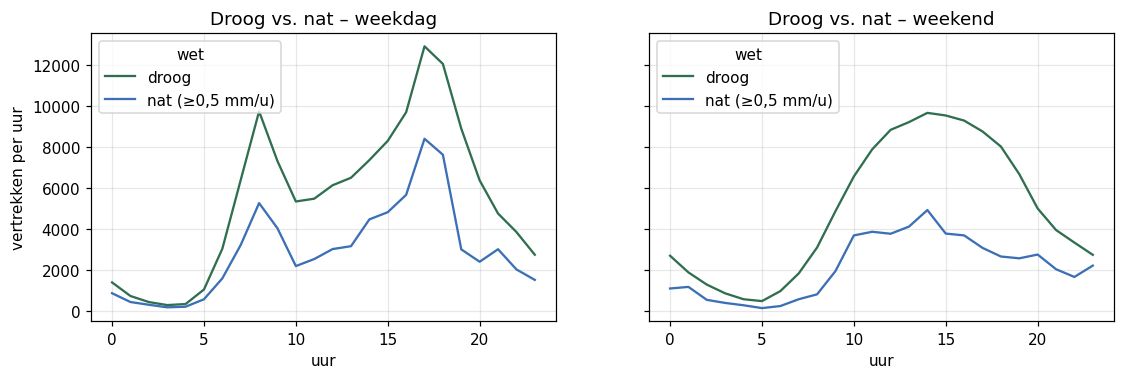

Uren per klasse: {'droog': 7504, 'motregen': 715, 'nat (≥0,5 mm/u)': 565}


In [16]:
# Regen: zelfde uur, zelfde daltype, droog vs. nat (eerste blik; de echte toets staat in 03).
city["wet"] = np.where(city["precipitation_mm"] >= 0.5, "nat (≥0,5 mm/u)", np.where(city["precipitation_mm"] == 0, "droog", "motregen"))
rain = city[city["wet"] != "motregen"].groupby(["daytype", "hour", "wet"])["trips"].mean().unstack()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True)
for ax, daytype in zip(axes, ["weekdag", "weekend"]):
    rain.loc[daytype].plot(ax=ax, color=[GREEN, "#3b6fb6"])
    ax.set(title=f"Droog vs. nat – {daytype}", xlabel="uur", ylabel="vertrekken per uur")
plt.show()
print("Uren per klasse:", city["wet"].value_counts().to_dict())

**Interpretatie:** bij regen (≥ 0,5 mm per uur) ligt de curve op elk uur duidelijk lager: op weekdagen ongeveer een derde, in het weekend zelfs meer dan de helft. Het weekendverkeer (vrije tijd) is gevoeliger voor regen dan het woon-werkverkeer: wie naar het werk moet, gaat toch.

Let op, dit is nog geen bewijs: misschien regent het vaker in de koude maanden (dan zou een deel van het verschil "winter" zijn). In `03_hypotheses` vergelijken we daarom alleen uren die verder gelijk zijn.

## 8. Waar? Stations groeperen tot zones (unsupervised: KMeans)
**Probleem:** per station per uur voorspellen geeft 2.000+ stations × 8.784 uren = 18 miljoen rijen, waarvan het grootste deel 0 of 1 vertrek. Dat is vooral ruis: of er om 14u één of twee mensen aan een rustig station vertrekken, is toeval. Voor herverdeling plant Citi Bike bovendien per buurt, niet per station.

**Aanpak:** we groeperen stations die dicht bij elkaar liggen met **KMeans** op hun coördinaten (omgerekend naar km, zodat noord-zuid en oost-west even zwaar wegen).
- **Gewogen met het aantal ritten** (`sample_weight`): KMeans legt de centra dan dichter bij elkaar waar veel gefietst wordt. Drukke buurten (Midtown) krijgen kleinere zones, rustige buurten (Bronx) grotere.
- **Hoeveel zones (k)?** Afweging: meer zones = fijner advies, maar minder ritten per zone-uur (meer ruis). We kijken naar de *inertia* (elleboogmethode), de *silhouette* en het aantal ritten per zone-uur.

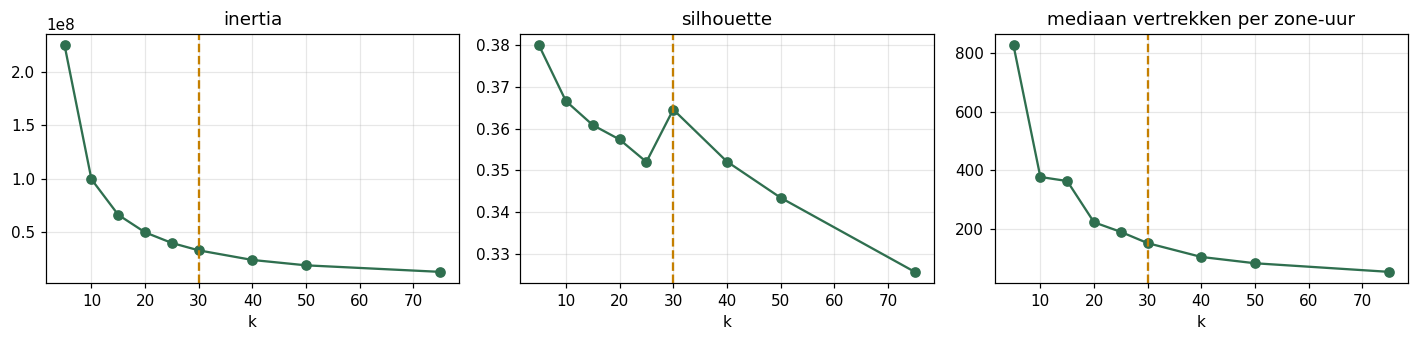

,inertia,silhouette,mediaan vertrekken per zone-uur,rustigste zone
k,,,,
5,2.252708e+08,0.38,826.58,389.73
10,9.938829e+07,0.37,377.45,187.99
15,6.589729e+07,0.36,363.62,73.02
20,4.941204e+07,0.36,222.71,72.85
25,3.941079e+07,0.35,189.83,63.33
30,3.248073e+07,0.36,151.45,24.36
40,2.344461e+07,0.35,104.26,23.26
50,1.839890e+07,0.34,82.75,22.72
75,1.224445e+07,0.33,53.33,13.48


In [17]:
from sklearn.metrics import silhouette_score

X_km = cb.to_km(public["lat"], public["lng"])
rows = []
for k in [5, 10, 15, 20, 25, 30, 40, 50, 75]:
    km = cb.fit_zones(public, k)
    labels = km.predict(X_km)
    sil = silhouette_score(X_km, labels, sample_size=2000, random_state=cb.SEED)
    per_zone = public.groupby(labels)["trips"].sum() / (366 * 24)
    rows.append({"k": k, "inertia": km.inertia_, "silhouette": sil,
                 "mediaan vertrekken per zone-uur": per_zone.median(), "rustigste zone": per_zone.min()})
choice = pd.DataFrame(rows).set_index("k")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, col in zip(axes, ["inertia", "silhouette", "mediaan vertrekken per zone-uur"]):
    ax.plot(choice.index, choice[col], "o-", color=GREEN)
    ax.axvline(cb.N_ZONES, color=ORANGE, ls="--")
    ax.set(title=col, xlabel="k")
plt.tight_layout()
plt.show()
choice.round(2)

**Interpretatie en keuze:** **k = 30**.
- **Inertia** (totale afstand tot het zonecentrum) daalt steil tot ± 20 à 30 zones en daarna nog maar langzaam: meer zones maken de groepen nauwelijks compacter (elleboog).
- De **silhouette** (hoe goed elk station bij zijn eigen zone past in plaats van bij de buurzone) ligt voor elke k tussen 0,33 en 0,38: de stations vormen geen natuurlijk gescheiden groepen (de stad is één doorlopend netwerk). De silhouette helpt dus niet om k te kiezen; de keuze is een **praktische afweging**.
- Met 30 zones telt een zone gemiddeld ± 75 stations (een buurt van een paar km²), is de mediane zone goed voor ± 150 vertrekken per uur, en heeft zelfs de rustigste zone nog gemiddeld 24 vertrekken per uur: genoeg signaal, geen telling die door toeval gedomineerd wordt. Bij 50 tot 75 zones zakt dat snel.

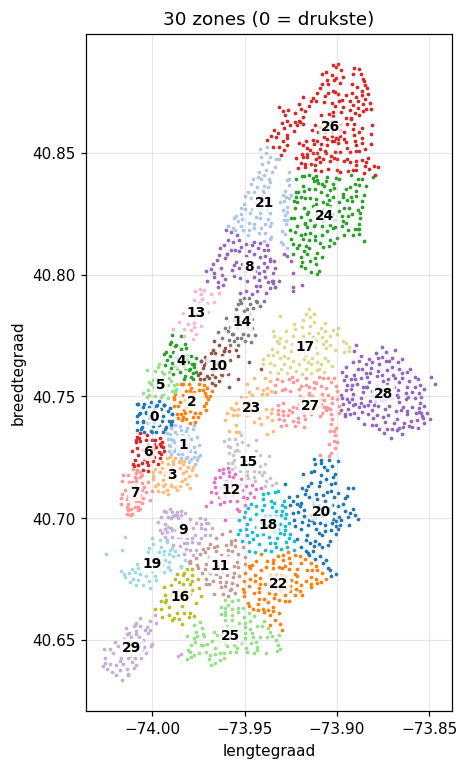

,zone,name,n_stations,trips
0,0,rond W 21 St & 6 Ave,51,3109617
1,1,rond University Pl & E 14 St,53,3071486
2,2,rond E 33 St & 1 Ave,48,2745216
3,3,rond Canal St & Rutgers St,55,2590015
4,4,rond Broadway & W 58 St,44,2543290
5,5,rond 8 Ave & W 31 St,37,2412386
6,6,rond Cleveland Pl & Spring St,43,2326064
7,7,rond West St & Chambers St,53,1961273
8,8,rond W 100 St & Broadway,89,1801415
9,9,rond Hanson Pl & Ashland Pl,64,1782047


In [18]:
kmeans = cb.fit_zones(public, cb.N_ZONES)
zones = cb.zone_table(public, kmeans)
public = public.assign(zone=cb.assign_zones(public, kmeans, zones).to_numpy())

fig, ax = plt.subplots(figsize=(7, 8))
cmap = plt.get_cmap("tab20")
for z in zones["zone"]:
    part = public[public["zone"] == z]
    ax.scatter(part["lng"], part["lat"], s=6, color=cmap(z % 20), lw=0)
for _, z in zones.iterrows():
    ax.text(z["lng"], z["lat"], str(z["zone"]), fontsize=9, weight="bold", ha="center", va="center",
            bbox=dict(boxstyle="round,pad=.15", fc="white", ec="none", alpha=.8))
ax.set(title=f"{cb.N_ZONES} zones (0 = drukste)", xlabel="lengtegraad", ylabel="breedtegraad")
ax.set_aspect(1 / np.cos(np.radians(40.73)))
plt.show()
zones[["zone", "name", "n_stations", "trips"]].head(10)

**Interpretatie:** door de weging met het aantal ritten zijn de zones in Lower Manhattan en Midtown (0 tot 6) klein en heel druk (elk meer dan 2 miljoen vertrekken per jaar), terwijl de zones in de Bronx (24, 26), Queens (17, 27, 28) en het zuiden van Brooklyn (25, 29) veel groter zijn, met 100 tot 200 stations per zone. Een zone is zo telkens "een gebied met genoeg ritten om te plannen". De naam van een zone is het drukste station erin.

## 9. Wat voor buurt is het? Stationsprofielen clusteren (unsupervised, deel 2)
De zones zeggen *waar*. Maar een zone in Midtown en een in Brooklyn gedragen zich misschien heel anders. Om dat te zien, clusteren we de stations een tweede keer, nu op hun **gedrag**: voor elk station het aandeel van zijn vertrekken per uur, apart voor weekdagen en weekend (48 getallen die samen 1 zijn). Zo vergelijken we de *vorm* van het dagpatroon, los van hoe druk een station is.

We nemen enkel stations met minstens 2.000 vertrekken in 2024, anders is het profiel te ruizig.

Inertia per k: {2: 6.237, 3: 5.322, 4: 4.912, 5: 4.584, 6: 4.335, 7: 4.124, 8: 3.971}


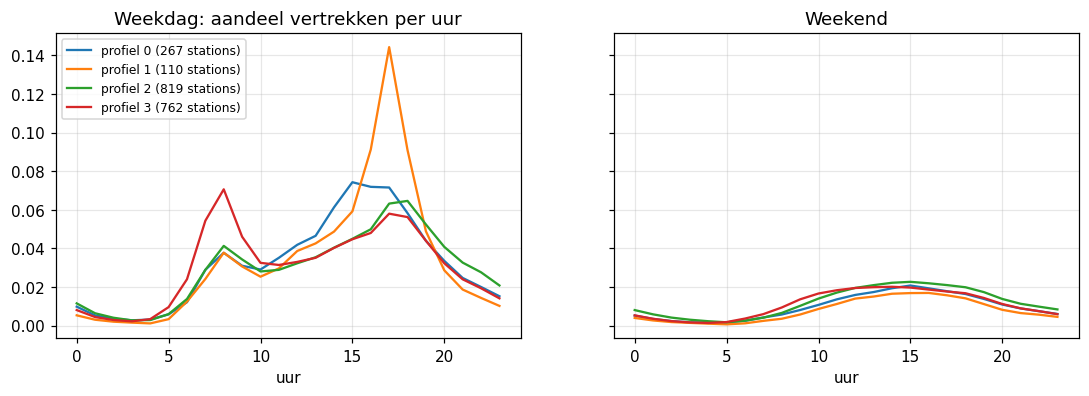

In [19]:
from sklearn.cluster import KMeans

sh = station_hour[station_hour["start_station_id"].isin(set(public.loc[public["trips"] >= 2000, "start_station_id"]))]
sh = sh.assign(slot=sh["time"].dt.hour + 24 * (sh["time"].dt.dayofweek >= 5))
prof = sh.pivot_table(index="start_station_id", columns="slot", values="trips", aggfunc="sum", fill_value=0)
prof = prof.div(prof.sum(axis=1), axis=0)

inertias = {k: KMeans(k, n_init=10, random_state=cb.SEED).fit(prof).inertia_ for k in range(2, 9)}
print("Inertia per k:", {k: round(v, 3) for k, v in inertias.items()})
behaviour = KMeans(4, n_init=10, random_state=cb.SEED).fit(prof)
prof_clusters = pd.Series(behaviour.labels_, index=prof.index, name="profiel")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for c in range(4):
    center = behaviour.cluster_centers_[c]
    n = int((prof_clusters == c).sum())
    axes[0].plot(range(24), center[:24], label=f"profiel {c} ({n} stations)")
    axes[1].plot(range(24), center[24:])
axes[0].set(title="Weekdag: aandeel vertrekken per uur", xlabel="uur"); axes[1].set(title="Weekend", xlabel="uur")
axes[0].legend(fontsize=8)
plt.show()

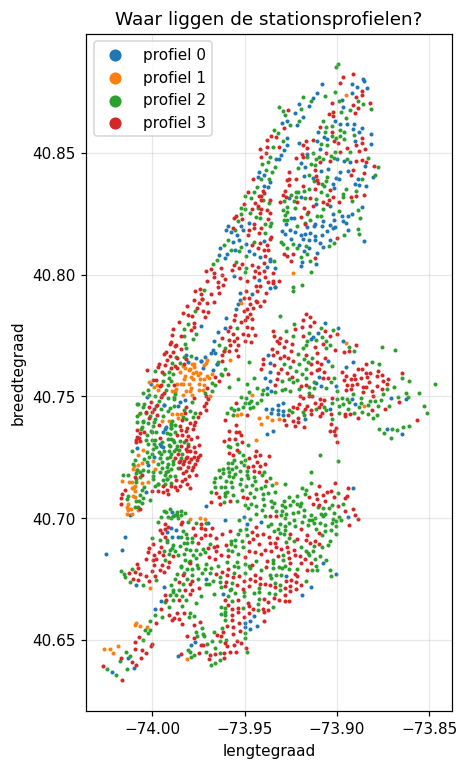

In [20]:
fig, ax = plt.subplots(figsize=(7, 8))
geo = public.set_index("start_station_id").join(prof_clusters, how="inner")
for c in range(4):
    part = geo[geo["profiel"] == c]
    ax.scatter(part["lng"], part["lat"], s=7, lw=0, label=f"profiel {c}")
ax.legend(markerscale=3)
ax.set(title="Waar liggen de stationsprofielen?", xlabel="lengtegraad", ylabel="breedtegraad")
ax.set_aspect(1 / np.cos(np.radians(40.73)))
plt.show()

**Interpretatie:** zonder dat we iets over buurten vertellen, vindt KMeans vier soorten stations met een duidelijk verschillend **weekdagpatroon** (in het weekend lijken ze sterk op elkaar):
- **profiel 3, woonbuurt** (762 stations): de grootste piek om **8u**. Mensen vertrekken 's ochtends van thuis. Verspreid over Upper East/West Side, Brooklyn en Queens.
- **profiel 1, kantoorwijk** (110 stations): een enorme piek om **17u** (14% van alle vertrekken in één uur!) en bijna geen ochtendpiek. Hier komen mensen 's ochtends *aan* en vertrekken ze 's avonds. Geconcentreerd in **Midtown** en het **Financial District**.
- **profiel 0** (267 stations): piek rond **15u**, vooral in Harlem en de Bronx. Dat valt samen met het einde van de schooldag.
- **profiel 2, gemengd** (819 stations): een avondpiek en relatief veel late-avondritten, in Lower Manhattan, Williamsburg en Long Island City (wonen + uitgaan).

**Wat leert dit ons voor het model?** Het dagpatroon hangt af van de **plaats**: een zone met veel kantoren piekt om 17u, een woonzone om 8u. Het model heeft dus de interactie **zone × uur × daltype** nodig. Een lineair model krijgt die alleen als we ze expliciet maken (05c); bomen vinden ze zelf (05d, 05e). Het verklaart ook waarom fietsen herverdeeld moeten worden: 's ochtends lopen woonbuurten leeg en kantoorwijken vol, 's avonds omgekeerd.

## 10. De target: vertrekken per zone per uur
**Vaststelling:** `station_hour` bevat alleen uren waarin minstens één fiets vertrok. Voor het model moeten de **lege uren expliciet als 0** in de tabel staan: anders leert het model alleen van uren met vraag en overschat het altijd.

Rooster: 263,520 zone-uren, waarvan 0.3% zonder vertrek
Gemiddelde: 168.0, variantie: 35416, max: 1881


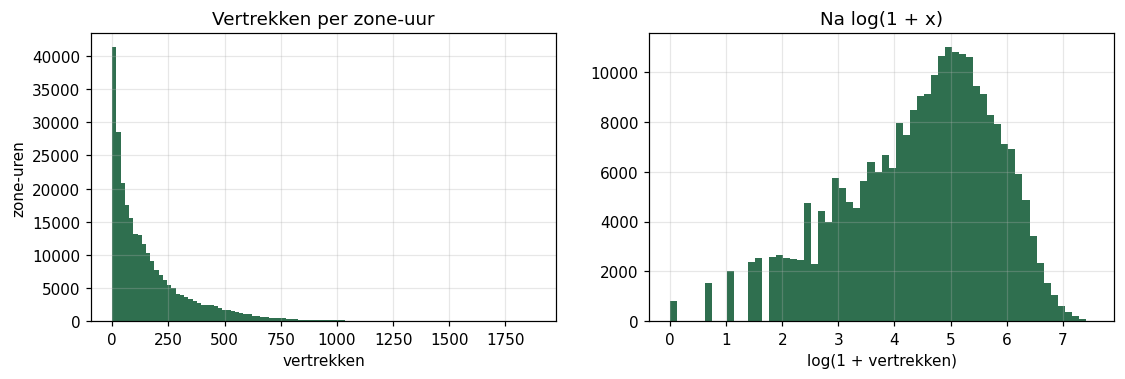

In [21]:
station_zone = public.set_index("start_station_id")["zone"]
grid = cb.build_zone_hour(station_hour, station_zone, cb.N_ZONES, weather)
print(f"Rooster: {len(grid):,} zone-uren, waarvan {(grid['trips'] == 0).mean():.1%} zonder vertrek")
print(f"Gemiddelde: {grid['trips'].mean():.1f}, variantie: {grid['trips'].var():.0f}, max: {grid['trips'].max()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].hist(grid["trips"], bins=100, color=GREEN)
axes[0].set(title="Vertrekken per zone-uur", xlabel="vertrekken", ylabel="zone-uren")
axes[1].hist(np.log1p(grid["trips"]), bins=60, color=GREEN)
axes[1].set(title="Na log(1 + x)", xlabel="log(1 + vertrekken)")
plt.show()

**Interpretatie:**
- Slechts 0,3% van de zone-uren heeft 0 vertrekken (vooral rustige zones 's nachts). Het expliciet toevoegen van die uren verandert dus weinig, maar is wel correct.
- De verdeling is **rechtsscheef** (gemiddeld 168, maximum 1.881 per uur) en de **variantie (± 35.000) is veel groter dan het gemiddelde**. Bij een zuivere Poisson-verdeling zijn die gelijk; hier is er sterke **overdispersie**, omdat de verwachting per uur en per zone sterk verschilt. Daarom kiezen we in 05 modellen met een **Poisson-verliesfunctie** (log-link: effecten zijn vermenigvuldigend) en meten we ook de Poisson-deviance.
- Uitschieters naar boven (drukke spitsuren) zijn **echte vraag**, geen meetfouten: die laten we staan.

### Is de data verbeterd?
We vergelijken wat we kregen met wat we nu hebben:

In [22]:
before = {"rijen": int(audit["rows"].sum()), "eenheid": "1 rit",
          "ontbrekende startlocaties": int(audit["no_start_station"].sum()),
          "dubbele station-id-notaties": int(audit["station_id_fixed"].sum()),
          "niet-publieke/JC-HB-vertrekken": int(st.loc[~st["keep"], "trips"].sum())}
after = {"rijen": len(grid), "eenheid": "1 zone-uur (incl. 0)", "ontbrekende startlocaties": 0,
         "dubbele station-id-notaties": 0, "niet-publieke/JC-HB-vertrekken": 0}
print(f"Vertrekken behouden: {grid['trips'].sum():,} van {int(audit['rows'].sum()):,} ruwe rijen "
      f"({grid['trips'].sum() / audit['rows'].sum():.2%})")
pd.DataFrame({"ruw": before, "na cleaning": after})

Vertrekken behouden: 44,269,890 van 44,303,209 ruwe rijen (99.92%)


,ruw,na cleaning
rijen,44303209,263520
eenheid,1 rit,1 zone-uur (incl. 0)
ontbrekende startlocaties,29835,0
dubbele station-id-notaties,350934,0
niet-publieke/JC-HB-vertrekken,3074,0


## Samenvatting van de keuzes (toegepast in `04_prepare_data`)
| Onderwerp | Vaststelling | Keuze |
|---|---|---|
| Kolomnamen/types | 2024 heeft één schema, alles als tekst | geen hernoeming; datums/getallen zelf omzetten |
| Ontbrekende start | 0,07% van de ritten, geen locatie | weglaten |
| Ontbrekend einde | 0,28%, vooral e-bikes, lange ritten | behouden (het is een vertrek) |
| Duplicaten | 0 dubbele `ride_id`'s | niets te doen |
| Station-id's | 350.934 id's als getal opgeslagen (`3423.1`) | normaliseren naar `3423.10` |
| Ritduur | lange en negatieve (klokwissel) ritten | niet filteren: target = vertrekken |
| Stations | 7 interne locaties, 63 JC/HB-stations (± 3.000 ritten) | weglaten |
| Categorieën | e-bike/classic, member/casual | `category`; niet als kenmerk (onbekend bij voorspellen) |
| Ruimtelijke eenheid | 2.211 stations, te veel ruis per station | 30 zones (gewogen KMeans) |
| Target | uren zonder vertrek ontbreken; sterke overdispersie | volledig rooster met 0; Poisson-modellen |
| Kenmerken | sterke effecten van uur × daltype × zone, seizoen/temperatuur, regen, feestdagen | zone, uur, weekdag, maand, weekend, feestdag, temperatuur, neerslag, wind |

Resultaat: **263.520 zone-uren** met in totaal 44,27 miljoen vertrekken (99,92% van de ruwe ritten).